# Instalando bibliotecas pip

In [1]:
!pip install s3fs boto3

INFO: pip is looking at multiple versions of aiobotocore to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of aiobotocore to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.0/102.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 4.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installa

# Importando bibliotecas no projeto

In [46]:
import boto3
import os
from getpass import getpass
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Chaves de acesso

In [3]:
os.environ["AWS_ACCESS_KEY_ID"] = getpass("AWS_ACCESS_KEY_ID: ")
os.environ["AWS_SECRET_ACCESS_KEY"] = getpass("AWS_SECRET_ACCESS_KEY: ")
os.environ["AWS_SESSION_TOKEN"] = getpass("AWS_SESSION_TOKEN: ")

AWS_ACCESS_KEY_ID: ··········
AWS_SECRET_ACCESS_KEY: ··········
AWS_SESSION_TOKEN: ··········


In [4]:
os.environ["AWS_DEFAULT_REGION"] = "us-east-1"

# Lab 01

## Acessar os dados na AWS

In [5]:
s3 = boto3.client("s3")

nome_bucket = "datalake-cd-senai-tb-raiano"

In [11]:
resposta = s3.list_objects_v2(Bucket=nome_bucket)
for objeto in resposta.get("Contents"):
  print(objeto["Key"])

dados_brutos/
dados_brutos/centro_logistico.csv
dados_tratados/


In [18]:
caminho_entrada = ("s3://" + nome_bucket + "/" + "dados_brutos/" + "centro_logistico.csv")
print(caminho_entrada)

s3://datalake-cd-senai-tb-raiano/dados_brutos/centro_logistico.csv


In [19]:
dados = pd.read_csv(caminho_entrada)
dados.head()

,id_registro,data_hora,centro_distribuicao,rota,turno,status_entrega,distancia_km,tempo_entrega_min,consumo_combustivel_l,temperatura_carga_c,peso_carga_kg,pedidos_transportados,atraso_min,ocupacao_veiculo_pct,custo_operacao_rs
0,1,01/03/2026 05:00:00,CD_Sul,Rota_B,Noite,No_Prazo,21.4,58,3.70,8.9,1098.0,54,0.0,59.1,112.52
1,2,01/03/2026 05:20:00,CD_Norte,Rota_B,Noite,NaN,45.0,86,5.08,6.6,567.1,85,4.0,37.8,157.61
2,3,01/03/2026 05:40:00,CD_Leste,Rota_E,Noite,Concluida,80.7,143,9.66,5.6,916.5,93,16.0,49.9,258.64
3,4,01/03/2026 06:00:00,CD_Leste,Rota_A,Manha,No_Prazo,29.6,80,3.42,7.0,539.7,60,7.0,28.8,133.38
4,5,01/03/2026 06:20:00,CD_Leste,Rota_E,Manha,Concluida,79.7,161,8.96,9.6,988.7,84,3.0,61.5,240.09


In [20]:
dados.isna().sum()

,0
id_registro,0
data_hora,0
centro_distribuicao,0
rota,0
turno,0
status_entrega,25
distancia_km,0
tempo_entrega_min,0
consumo_combustivel_l,25
temperatura_carga_c,25


## Criar uma cópia da tabela para tratamento


In [21]:
dados_limpos = dados.copy()

In [22]:
dados_limpos.dropna(inplace=True)

In [23]:
caminho_saida = ("s3://" + nome_bucket + "/" + "dados_tratados/" + "centro_logistico_tratado.csv")
print(caminho_saida)

s3://datalake-cd-senai-tb-raiano/dados_tratados/centro_logistico_tratado.csv


In [24]:
dados_limpos.to_csv(caminho_saida, index=False)

In [25]:
dados_limpos["status_entrega"].unique()

array(['No_Prazo', 'Concluida', 'Em_Rota', 'Atrasada'], dtype=object)

In [28]:
mapa = {
    "No_Prazo" : "No Prazo",
    "Atrasada" : "Atrasada",
    "Concluida" : "Concluida",
    "Em_Rota" : "EmRota"
}
dados_limpos["status_entrega"] = dados_limpos["status_entrega"].map(mapa)

In [29]:
dados_limpos.to_csv(caminho_saida, index=False)

## Gerando um gráfico para enviar ao bucket

In [ ]:
dados_limpos["atraso_min"]

In [ ]:
dados_limpos["centro_distribuicao"].unique()

In [34]:
dados_atraso_media = dados.groupby("centro_distribuicao", as_index=False)["atraso_min"].mean()

In [37]:
caminho_saida_atrasos = ("s3://" + nome_bucket + "/" + "resultados/" + "atrasos_minutos.csv")
print(caminho_saida_atrasos)

s3://datalake-cd-senai-tb-raiano/resultados/atrasos_minutos.csv


In [38]:
dados_atraso_media.to_csv(caminho_saida_atrasos, index=False)

In [39]:
caminho_entrada_atrasos = ("s3://" + nome_bucket + "/" + "resultados/" + "atrasos_minutos.csv")
print(caminho_entrada_atrasos)

s3://datalake-cd-senai-tb-raiano/resultados/atrasos_minutos.csv


In [40]:
dados = pd.read_csv(caminho_entrada_atrasos)
dados.head()

,centro_distribuicao,atraso_min
0,CD_Leste,7.076146
1,CD_Norte,7.554487
2,CD_Oeste,7.554823
3,CD_Sul,7.718826


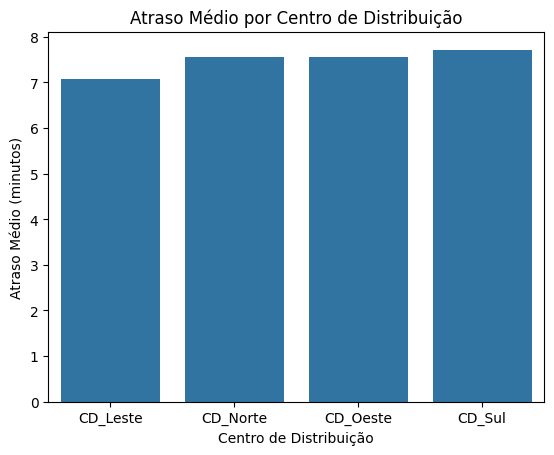

In [52]:
sns.barplot(data=dados_atraso_media, x="centro_distribuicao", y="atraso_min")
plt.title("Atraso Médio por Centro de Distribuição")
plt.xlabel("Centro de Distribuição")
plt.ylabel("Atraso Médio (minutos)")
plt.savefig("atrasos_por_centro.png")
plt.show()

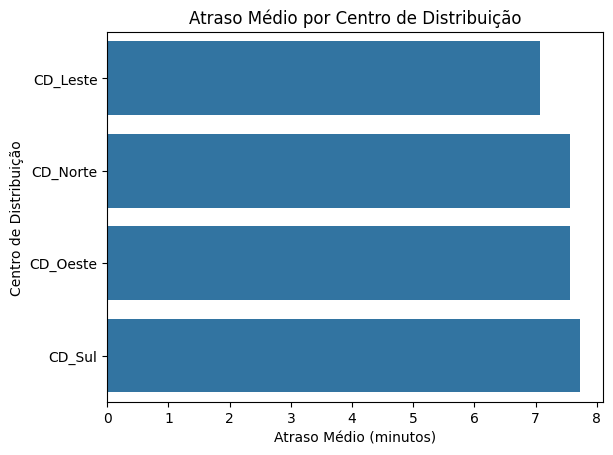

In [51]:
sns.barplot(data=dados_atraso_media, y="centro_distribuicao", x="atraso_min")
plt.title("Atraso Médio por Centro de Distribuição")
plt.ylabel("Centro de Distribuição")
plt.xlabel("Atraso Médio (minutos)")
plt.savefig("atrasos_por_centro_2.png")
plt.show()

In [53]:
s3.upload_file("/content/atrasos_por_centro.png", nome_bucket, "resultados/atrasos_por_centro.png")
s3.upload_file("/content/atrasos_por_centro_2.png", nome_bucket, "resultados/atrasos_por_centro_2.png")

# Lab 02

In [55]:
caminho = caminho_saida = ("s3://" + nome_bucket + "/" + "dados_tratados/" + "centro_logistico_tratado.csv")
dados_lab02 = pd.read_csv(caminho)
dados_lab02.head()

,id_registro,data_hora,centro_distribuicao,rota,turno,status_entrega,distancia_km,tempo_entrega_min,consumo_combustivel_l,temperatura_carga_c,peso_carga_kg,pedidos_transportados,atraso_min,ocupacao_veiculo_pct,custo_operacao_rs
0,1,01/03/2026 05:00:00,CD_Sul,Rota_B,Noite,No Prazo,21.4,58,3.70,8.9,1098.0,54,0.0,59.1,112.52
1,3,01/03/2026 05:40:00,CD_Leste,Rota_E,Noite,Concluida,80.7,143,9.66,5.6,916.5,93,16.0,49.9,258.64
2,4,01/03/2026 06:00:00,CD_Leste,Rota_A,Manha,No Prazo,29.6,80,3.42,7.0,539.7,60,7.0,28.8,133.38
3,5,01/03/2026 06:20:00,CD_Leste,Rota_E,Manha,Concluida,79.7,161,8.96,9.6,988.7,84,3.0,61.5,240.09
4,6,01/03/2026 06:40:00,CD_Leste,Rota_B,Manha,EmRota,31.6,89,4.58,9.9,943.4,61,0.0,51.2,128.80


In [56]:
dados_lab02.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4900 entries, 0 to 4899
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_registro            4900 non-null   int64  
 1   data_hora              4900 non-null   object 
 2   centro_distribuicao    4900 non-null   object 
 3   rota                   4900 non-null   object 
 4   turno                  4900 non-null   object 
 5   status_entrega         4900 non-null   object 
 6   distancia_km           4900 non-null   float64
 7   tempo_entrega_min      4900 non-null   int64  
 8   consumo_combustivel_l  4900 non-null   float64
 9   temperatura_carga_c    4900 non-null   float64
 10  peso_carga_kg          4900 non-null   float64
 11  pedidos_transportados  4900 non-null   int64  
 12  atraso_min             4900 non-null   float64
 13  ocupacao_veiculo_pct   4900 non-null   float64
 14  custo_operacao_rs      4900 non-null   float64
dtypes: f

In [59]:
dados_lab02["data_hora"]

,data_hora
0,2026-03-01 05:00:00
1,2026-03-01 05:40:00
2,2026-03-01 06:00:00
3,2026-03-01 06:20:00
4,2026-03-01 06:40:00
...,...
4895,2026-05-09 14:00:00
4896,2026-05-09 14:20:00
4897,2026-05-09 14:40:00
4898,2026-05-09 15:00:00


In [60]:
pd.to_datetime(dados_lab02["data_hora"], format="%d/%m/%Y %H:%M:%S")

,data_hora
0,2026-03-01 05:00:00
1,2026-03-01 05:40:00
2,2026-03-01 06:00:00
3,2026-03-01 06:20:00
4,2026-03-01 06:40:00
...,...
4895,2026-05-09 14:00:00
4896,2026-05-09 14:20:00
4897,2026-05-09 14:40:00
4898,2026-05-09 15:00:00


In [58]:
dados_lab02["data_hora"] = pd.to_datetime(dados_lab02["data_hora"], format="%d/%m/%Y %H:%M:%S")

In [61]:
dados_lab02.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4900 entries, 0 to 4899
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_registro            4900 non-null   int64         
 1   data_hora              4900 non-null   datetime64[ns]
 2   centro_distribuicao    4900 non-null   object        
 3   rota                   4900 non-null   object        
 4   turno                  4900 non-null   object        
 5   status_entrega         4900 non-null   object        
 6   distancia_km           4900 non-null   float64       
 7   tempo_entrega_min      4900 non-null   int64         
 8   consumo_combustivel_l  4900 non-null   float64       
 9   temperatura_carga_c    4900 non-null   float64       
 10  peso_carga_kg          4900 non-null   float64       
 11  pedidos_transportados  4900 non-null   int64         
 12  atraso_min             4900 non-null   float64       
 13  ocu

In [63]:
dados_lab02["data_hora"].dt.date

,data_hora
0,2026-03-01
1,2026-03-01
2,2026-03-01
3,2026-03-01
4,2026-03-01
...,...
4895,2026-05-09
4896,2026-05-09
4897,2026-05-09
4898,2026-05-09


In [79]:
res = dados_lab02.groupby(dados_lab02["data_hora"].dt.date)["atraso_min"].mean()
res = res.reset_index()

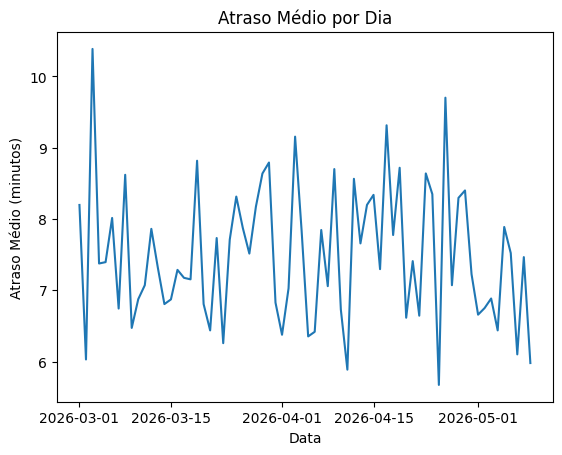

In [83]:
sns.lineplot(data=res, x="data_hora", y="atraso_min")
plt.title("Atraso Médio por Dia")
plt.xlabel("Data")
plt.ylabel("Atraso Médio (minutos)")
plt.savefig("atrasos_por_dia.png")
plt.show()

In [84]:
caminho_parquet = ("s3://" + nome_bucket + "/" + "dados_parquet/" + "centro_log_tratado.parquet")
print(caminho_parquet)

s3://datalake-cd-senai-tb-raiano/dados_parquet/centro_log_tratado.parquet


In [85]:
dados_lab02.to_parquet(caminho_parquet, index=False)

In [86]:
teste = pd.read_parquet(caminho_parquet)
teste.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4900 entries, 0 to 4899
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_registro            4900 non-null   int64         
 1   data_hora              4900 non-null   datetime64[ns]
 2   centro_distribuicao    4900 non-null   object        
 3   rota                   4900 non-null   object        
 4   turno                  4900 non-null   object        
 5   status_entrega         4900 non-null   object        
 6   distancia_km           4900 non-null   float64       
 7   tempo_entrega_min      4900 non-null   int64         
 8   consumo_combustivel_l  4900 non-null   float64       
 9   temperatura_carga_c    4900 non-null   float64       
 10  peso_carga_kg          4900 non-null   float64       
 11  pedidos_transportados  4900 non-null   int64         
 12  atraso_min             4900 non-null   float64       
 13  ocu